In [33]:
import plotly.express as px
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

df = px.data.iris()
df = df[df["species"].isin(["setosa", "versicolor"])]  # Выбираем 2 класса

X = df[["sepal_length", "petal_width"]].values
y = (df["species"] == "versicolor").astype(int)

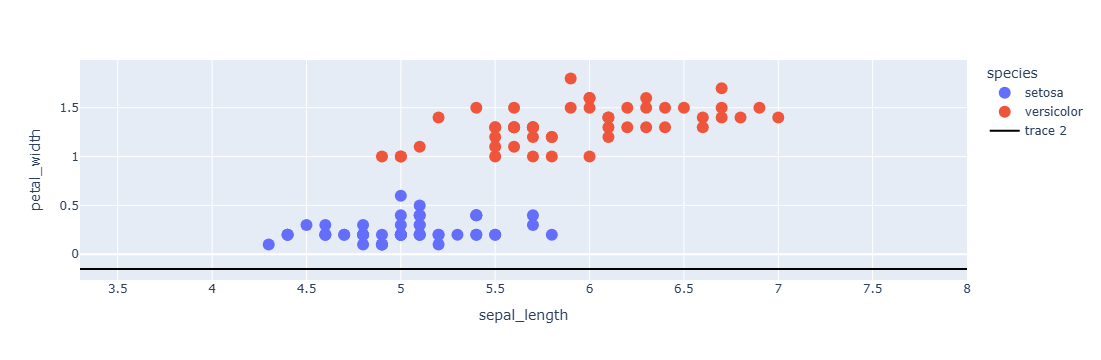

In [35]:
# 1. Метод опорных векторов
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

svm = SVC(kernel="linear")
svm.fit(X_scaled, y)

fig = px.scatter(df, x="sepal_length", y="petal_width", color="species")
fig.update_traces(marker=dict(size=12))

x_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
y_range = -(svm.coef_[0][0] * x_range + svm.intercept_[0]) / svm.coef_[0][1]
fig.add_scatter(x=x_range, y=y_range, mode="lines", line=dict(color="black", width=2))

fig.show()

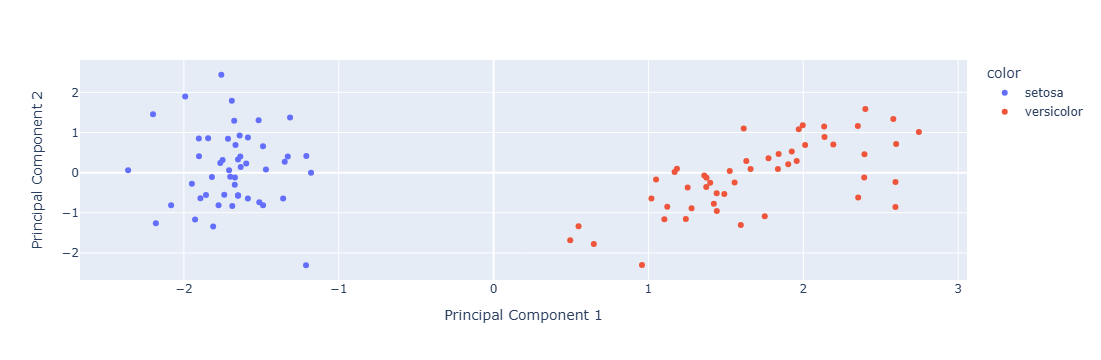

In [37]:
# 2. Метод главных компонент

from sklearn.decomposition import PCA

X = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].values
X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

fig = px.scatter(x=X_pca[:, 0], y=X_pca[:, 1], color=df["species"])
fig.update_layout(
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2",
)
fig.show()

C:\Users\Public\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



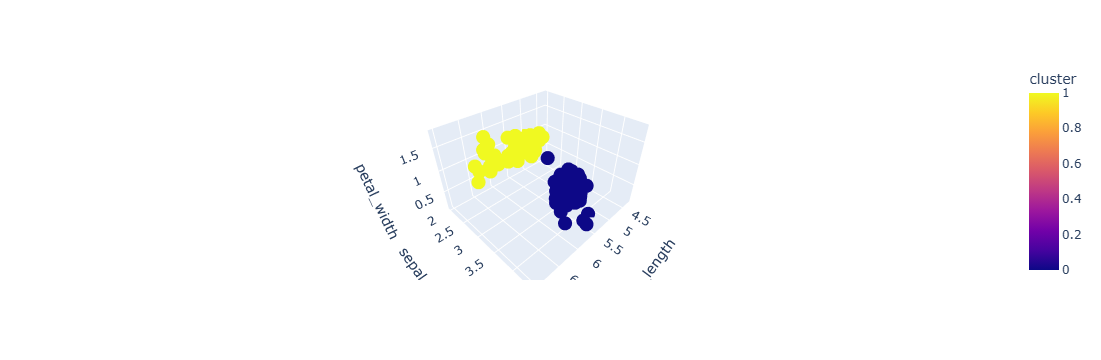

In [39]:
# 3. Метод k средних
from sklearn.cluster import KMeans

X = df[["sepal_length", "sepal_width", "petal_width"]].values
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
df["cluster"] = kmeans.labels_

fig = px.scatter_3d(
    df, x="sepal_length", y="sepal_width", z="petal_width", color="cluster"
)
fig.show()